%md
# Actividad 3 — Proyecto Integrador: Transformación, Limpieza y Visualización de Datos en Databricks
**Autor:** Jhon Jader Benítez Valderrama  
**Grupo:** 10  
**Empresa:** Portosoft S.A.S  
**Curso:** Big Data  
---

## Objetivo
Aplicar transformaciones de fecha, generar resúmenes mensuales, realizar limpieza con evidencia antes/después y construir visualizaciones categóricas utilizando Databricks Community Edition con PySpark, SQL y librerías de análisis.

Este proyecto constituye la evidencia final del curso e incluye:

1. Creación de columnas derivadas de fecha.  
2. Construcción de un resumen mensual del dataset.  
3. Limpieza de datos con comparación antes/después.  
4. Visualizaciones categóricas con matplotlib / seaborn / plotly.  
5. Exportación del notebook y elaboración de un video explicativo.

---


##1. Cargar tabla

In [0]:
df = spark.table("portosoft_catalog.jobs_schema.tbl_jobs_spk")



## 2. Crear columnas de año y mes (necesarias para el resumen mensual)

In [0]:
from pyspark.sql import functions as F

df = df.withColumn("first_seen_date", F.to_date("first_seen"))

df = (
    df.withColumn("anio", F.year("first_seen_date"))
      .withColumn("mes", F.month("first_seen_date"))
)


## 3. Crear tabla resumen mensual con PySpark
Mi dtaset tiene monto ni id numérico, así que usaremos métricas útiles:

Número de ofertas por mes

Número de empresas únicas

Número de ciudades únicas

Número de niveles de trabajo

In [0]:
resumen_mensual = (
    df.groupBy("anio", "mes")
      .agg(
          F.count("*").alias("n_ofertas"),
          F.countDistinct("company").alias("empresas_unicas"),
          F.countDistinct("search_city").alias("ciudades_unicas"),
          F.countDistinct("job_level").alias("niveles_laborales")
      )
)

resumen_mensual.write.mode("overwrite").saveAsTable(
    "portosoft_catalog.jobs_schema.resumen_mensual_jobs"
)


## 4. Crear tabla resumen mensual con SQL

In [0]:
%sql
CREATE OR REPLACE TABLE portosoft_catalog.jobs_schema.resumen_mensual_jobs_sql AS
SELECT
    YEAR(TO_DATE(first_seen))  AS anio,
    MONTH(TO_DATE(first_seen)) AS mes,
    COUNT(*)                   AS n_ofertas,
    COUNT(DISTINCT company)    AS empresas_unicas,
    COUNT(DISTINCT search_city) AS ciudades_unicas,
    COUNT(DISTINCT job_level)   AS niveles_laborales
FROM portosoft_catalog.jobs_schema.tbl_jobs_spk
GROUP BY anio, mes
ORDER BY anio, mes;


num_affected_rows,num_inserted_rows


## 5. Mostrar evidencia

In [0]:
%sql
SELECT * FROM portosoft_catalog.jobs_schema.resumen_mensual_jobs LIMIT 10;


anio,mes,n_ofertas,empresas_unicas,ciudades_unicas,niveles_laborales
2023,12,9380,3373,709,2


##6. Limpieza: evidencia antes / después
###6.1 Antes

In [0]:
df_before = df
display(df_before.select("company", "job_title", "search_city", "job_level").limit(10))


company,job_title,search_city,job_level
"Veridian Tech Solutions, Inc.",Software Engineer,West Des Moines,Mid senior
Source Allies,Software Engineer,West Des Moines,Mid senior
Accroid Inc,Senior Software Engineer,West Des Moines,Mid senior
Open Systems Inc.,Senior Software Engineer,West Des Moines,Mid senior
Apex Systems,Java Software Engineer,West Des Moines,Mid senior
"Changing Technologies, Inc.",Senior Software Engineer,West Des Moines,Mid senior
Veracity Software Inc,"Senior Software Engineer (Java, React, AWS (Cloud), Spring-boot based app dev)",West Des Moines,Mid senior
MidAmerican Energy Company,Software Engineer I/II or III,West Des Moines,Mid senior
Source Allies,Software Engineer,West Des Moines,Mid senior
Robert Half,Software Developer,West Des Moines,Mid senior


###6.2 Transformaciones de limpieza

In [0]:
from pyspark.sql import functions as F, types as T

df_clean = df

# 1) Limpieza de texto (trim + lower)
df_clean = (
    df_clean.withColumn("company_clean", F.lower(F.trim("company")))
            .withColumn("city_clean", F.lower(F.trim("search_city")))
            .withColumn("title_clean", F.lower(F.trim("job_title")))
)

# 2) Imputación de nulos (ejemplo simple)
df_clean = df_clean.fillna({
    "job_level": "unknown",
    "job_type": "unknown"
})

# 3) Conversión de fechas asegurada
df_clean = df_clean.withColumn("first_seen_date", F.to_date("first_seen"))


###6.3 Después

In [0]:
display(df_clean.select(
    "company_clean",
    "city_clean",
    "title_clean",
    "job_level"
).limit(10))


company_clean,city_clean,title_clean,job_level
"veridian tech solutions, inc.",west des moines,software engineer,Mid senior
source allies,west des moines,software engineer,Mid senior
accroid inc,west des moines,senior software engineer,Mid senior
open systems inc.,west des moines,senior software engineer,Mid senior
apex systems,west des moines,java software engineer,Mid senior
"changing technologies, inc.",west des moines,senior software engineer,Mid senior
veracity software inc,west des moines,"senior software engineer (java, react, aws (cloud), spring-boot based app dev)",Mid senior
midamerican energy company,west des moines,software engineer i/ii or iii,Mid senior
source allies,west des moines,software engineer,Mid senior
robert half,west des moines,software developer,Mid senior


##7. Visualizaciones con matplotlib / seaborn / plotly

Para visualizar necesitamos convertir a pandas:

In [0]:
pdf = df_clean.select(
    "company_clean", "city_clean", "job_type", "anio", "mes"
).toPandas()


##Ejemplo 1 — Conteo por tipo de trabajo (seaborn)

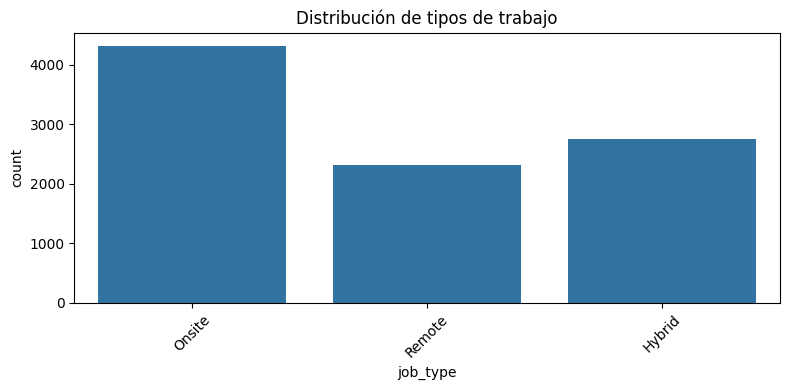

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.countplot(data=pdf, x="job_type")
plt.xticks(rotation=45)
plt.title("Distribución de tipos de trabajo")
plt.tight_layout()
plt.show()


La gráfica muestra la cantidad de ofertas por tipo de trabajo.

Se observa qué modalidad (remote / hybrid / onsite) es más común.

Permite identificar la preferencia del mercado laboral actual

##Ejemplo 2 — Ofertas por mes (plotly)

In [0]:
import plotly.express as px

fig = px.bar(pdf, x="mes", color="job_type", title="Ofertas por mes por tipo de trabajo")
fig.show()


Muestra cómo varía la cantidad de ofertas entre meses.

Permite detectar estacionalidad.

Resalta si algún tipo de trabajo aumenta en un mes específico.